In [39]:
import numpy as np 
import torch
import torch.nn as nn
from torch.utils.data import DataLoader , TensorDataset
from sklearn.datasets import load_wine
import torch.nn.functional as F
import matplotlib.pyplot as plt
wine=load_wine()

print(wine.DESCR)


.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [40]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train ,y_test=train_test_split(X,y , test_size=0.2 , random_state=101)

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()        
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) 

X_train=torch.tensor(X_train, dtype=torch.float32)
y_train=torch.tensor( y_train,dtype=torch.long)
X_test=torch.tensor(X_test, dtype=torch.float32)
y_test=torch.tensor( y_test,dtype=torch.long)

train_data=TensorDataset(X_train , y_train)
test_data=TensorDataset(X_test  , y_test)

train_loader = DataLoader(train_data, batch_size=32,drop_last=True , shuffle=True)
test_loader = DataLoader(test_data, batch_size=len(test_data), shuffle=False)



/tmp/ipykernel_23419/1851773011.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train=torch.tensor( y_train,dtype=torch.long)
/tmp/ipykernel_23419/1851773011.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test=torch.tensor( y_test,dtype=torch.long)


In [41]:
# create a class for the model WITH BATCH NORM

class ANNwine_withBNorm(nn.Module):
  def __init__(self):
    super().__init__()

    ### input layer
    self.input = nn.Linear(13,16)
    
    ### hidden layers
    self.fc1    = nn.Linear(16,32)
    self.bnorm1 = nn.BatchNorm1d(16) # the number of units into this layer
    self.fc2    = nn.Linear(32,20)
    self.bnorm2 = nn.BatchNorm1d(32) # the number of units into this layer

    ### output layer
    self.output = nn.Linear(20,3)
  
  # forward pass
  def forward(self,x,doBN):

    # input (x starts off normalized)
    x = F.relu( self.input(x) )


    if doBN:
      # hidden layer 1
      x = self.bnorm1(x) # batchnorm
      x = self.fc1(x)    # weighted combination
      x = F.relu(x)      # activation function

      # hidden layer 2
      x = self.bnorm2(x) # batchnorm
      x = self.fc2(x)    # weighted combination
      x = F.relu(x)      # activation function
    

    else:
      # hidden layer 1
      x = F.relu( self.fc1(x) )

      # hidden layer 2
      x = F.relu( self.fc2(x) )

    # output layer
    return self.output(x)

In [42]:
winenet = ANNwine_withBNorm()

numepochs = 1000

def trainTheModel(doBN=True):

  lossfun = nn.CrossEntropyLoss()
  optimizer = torch.optim.SGD(winenet.parameters(), lr=0.01)

  losses   = torch.zeros(numepochs)
  trainAcc = []
  testAcc  = []

  for epochi in range(numepochs):

    winenet.train()

    batchAcc  = []
    batchLoss = []

    for X, y in train_loader:

      # forward
      yHat = winenet(X, doBN)
      loss = lossfun(yHat, y)

      # backward
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batchLoss.append(loss.item())

      # ✅ FIX 1: correct training accuracy
      preds = torch.argmax(yHat, dim=1)
      acc = 100 * torch.mean((preds == y).float()).item()
      batchAcc.append(acc)

    trainAcc.append(np.mean(batchAcc))
    losses[epochi] = np.mean(batchLoss)

    # ===== TEST =====
    winenet.eval()

    X, y = next(iter(test_loader))

    with torch.no_grad():
      yHat = winenet(X, doBN)

      # ✅ FIX 2: correct test accuracy
      preds = torch.argmax(yHat, dim=1)
      acc = 100 * torch.mean((preds == y).float()).item()
      testAcc.append(acc)

  return trainAcc, testAcc, losses

In [ ]:


# create and train a model NO BATCHNORM
winenet = ANNwine_withBNorm()
trainAccNo,testAccNo,lossesNo = trainTheModel(False)

# create and train a model WITH BATCHNORM
winenet = ANNwine_withBNorm()
trainAccWith,testAccWith,lossesWith = trainTheModel(True)


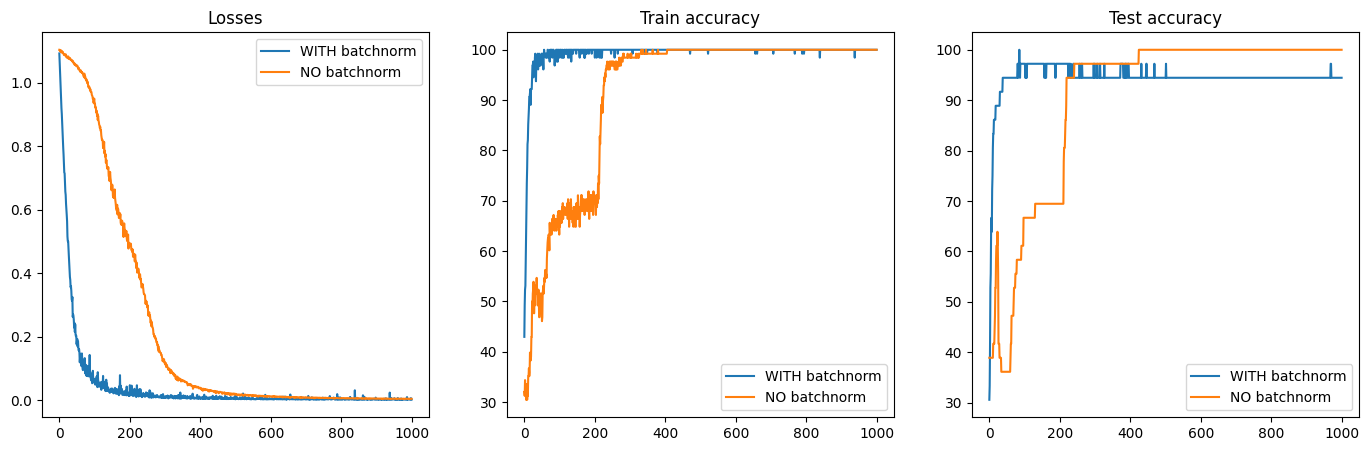

In [44]:
# plot the results
fig,ax = plt.subplots(1,3,figsize=(17,5))

ax[0].plot(lossesWith,label='WITH batchnorm')
ax[0].plot(lossesNo,label='NO batchnorm')
ax[0].set_title('Losses')
ax[0].legend()

ax[1].plot(trainAccWith,label='WITH batchnorm')
ax[1].plot(trainAccNo,label='NO batchnorm')
ax[1].set_title('Train accuracy')
ax[1].legend()

ax[2].plot(testAccWith,label='WITH batchnorm')
ax[2].plot(testAccNo,label='NO batchnorm')
ax[2].set_title('Test accuracy')
ax[2].legend()

plt.show()